# **NBA Clutch Performance**

**Author:** Alejandro Magdiel Muniz Corona  
**Last updated:** 2026  
**Data source:** [nba_api](https://github.com/swar/nba_api)

## What is **'Clutch'**?

The NBA defines **clutch time** as the last **5 minutes** of the 4th quarter (or overtime) when the score difference is **5 points or less**. It measures a player's ability to perform when the **game is on the line**, the minutes that decide winners from losers

This notebook analyzes how players perform under that pressure:
- Who scores the most in clutch moments?
- Who shoots efficiently when it matters?
- Who handles the ball (assists vs turnovers)?
- How do clutch stats compare to overall season stats?

## Sections

1. [Setup & Imports](#1-setup--imports)
2. [Data Collection](#2-data-collection)
3. [Data Cleaning & Preparation](#3-data-cleaning--preparation)
4. [Exploratory Analysis](#4-exploratory-analysis)
5. [Clutch vs Overall Stats Comparison](#5-clutch-vs-overall-stats-comparison)
6. [Interactive Dashboard](#6-interactive-dashboard)
7. [Key Insights](#7-key-insights)

## 1. Setup & Imports

Install dependencies if needed, then import everything.

**First time?** Run this in your terminal before opening the notebook:

```bash
pip install nba_api pandas matplotlib seaborn plotly nbformat
```

Or directly inside a notebook cell:

```bash
!pip install nba_api pandas matplotlib seaborn plotly nbformat
```

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Regression
from numpy.polynomial import polynomial as P

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NBA API
from nba_api.stats.endpoints import leaguedashplayerclutch, leaguedashplayerstats

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
nba_cmap = mcolors.LinearSegmentedColormap.from_list('nba', ['#c8102e', '#ffffff', '#1d428a'])
nba_plotly_scale = ['#c8102e', '#ffffff', '#1d428a']

pd.set_option('display.max_columns', None)

## 2. Data Collection

We pull two datasets from the NBA Stats API:
- **Clutch stats**: player performance in clutch situations (last 5 min, ≤5 pt game)
- **Overall stats**: full season averages for comparison

In [2]:
SEASON = '2025-26' # Define the season to analyze

print(f'Fetching clutch stats for {SEASON} season...')

# Clutch stats
# Calling the API to get clutch stats for players in the specified season. 
# 'PerGame' mode is used to get per game averages, which allows for better comparability between players with different amounts of playing time.
clutch_response = leaguedashplayerclutch.LeagueDashPlayerClutch(
    season=SEASON,
    per_mode_detailed='PerGame',
)

# Extracting the clutch data into a DataFrame and printing its shape to understand how many players and statistics are included in the dataset.
df_clutch = clutch_response.get_data_frames()[0]
print(f'  Clutch data: {df_clutch.shape[0]} players, {df_clutch.shape[1]} columns')

Fetching clutch stats for 2025-26 season...
  Clutch data: 492 players, 68 columns


In [3]:
# Overall season stats
# Calling the API to get overall season stats for players in the specified season.
print(f'Fetching overall season stats for {SEASON}...')
overall_response = leaguedashplayerstats.LeagueDashPlayerStats(
    season=SEASON,
    per_mode_detailed='PerGame',
)

# Extracting the overall season data into a DataFrame and printing its shape to understand how many players and statistics are included in the dataset.
df_overall = overall_response.get_data_frames()[0]
print(f'  Overall data: {df_overall.shape[0]} players, {df_overall.shape[1]} columns')


Fetching overall season stats for 2025-26...
  Overall data: 582 players, 67 columns


Apparently, there is a column that is in the clutch stats dataframe (`df_clutch`), but it's not in the overall season stats (`df_overal`).

In [4]:
# Checking for columns that are present in the clutch stats but not in the overall season stats. 
# This is important to understand if there are any unique statistics that are only available in the clutch dataset, which could be crucial for our analysis.
for col in df_clutch.columns:
    if col not in df_overall.columns:
        print(f'Column "{col}" is in clutch stats but not in overall stats.')


Column "GROUP_SET" is in clutch stats but not in overall stats.


Analysis of the possible values for this column:

In [5]:
df_clutch['GROUP_SET'].unique()

<StringArray>
['Players']
Length: 1, dtype: str

The column has only one possible value, which indicates it's not important for this analysis.

Now the retrieved data is analyzed.

There are more players in the `overall` dataset because not every player in the league who gets playing time during the season ends up playing in clutch situations.

In [6]:
# Verifying that all players in the clutch stats are also present in the overall season stats.

for player in df_clutch['PLAYER_NAME'].unique():
    if player not in df_overall['PLAYER_NAME'].values:
        print(f'Player "{player}" is in clutch stats but not in overall stats.')

In [7]:
for player in df_overall['PLAYER_NAME'].unique():
    if player not in df_clutch['PLAYER_NAME'].values:
        print(f'Player "{player}" is in overall stats but not in clutch stats.')

Player "Adou Thiero" is in overall stats but not in clutch stats.
Player "Alex Antetokounmpo" is in overall stats but not in clutch stats.
Player "Alex Morales" is in overall stats but not in clutch stats.
Player "Antonio Reeves" is in overall stats but not in clutch stats.
Player "Bismack Biyombo" is in overall stats but not in clutch stats.
Player "Blake Wesley" is in overall stats but not in clutch stats.
Player "Bobi Klintman" is in overall stats but not in clutch stats.
Player "Bradley Beal" is in overall stats but not in clutch stats.
Player "Branden Carlson" is in overall stats but not in clutch stats.
Player "Brooks Barnhizer" is in overall stats but not in clutch stats.
Player "Buddy Boeheim" is in overall stats but not in clutch stats.
Player "CJ Huntley" is in overall stats but not in clutch stats.
Player "Caleb Houstan" is in overall stats but not in clutch stats.
Player "Cam Christie" is in overall stats but not in clutch stats.
Player "Chris Mañon" is in overall stats but

There are some very interesting names that didn’t get to play in clutch situations. For example, Bradley Beal, one of the league’s biggest stars, missed time due to injury. Another notable case is future Hall of Famer Chris Paul, who was waived by the Los Angeles Clippers early in the season.

### Cluch Statistics

In [8]:
# Quick look at the raw data
print('Clutch stats columns:')
print(df_clutch.columns.tolist())

Clutch stats columns:
['GROUP_SET', 'PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT']


In [9]:
print('\nSample rows from clutch stats:')
df_clutch[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'MIN', 'FGA', 'FGM', 'FG_PCT', 'PTS', 'REB', 'AST', 'TOV', 'PLUS_MINUS', 'W_PCT']].head(40)


Sample rows from clutch stats:


,PLAYER_NAME,TEAM_ABBREVIATION,GP,MIN,FGA,FGM,FG_PCT,PTS,REB,AST,TOV,PLUS_MINUS,W_PCT
0,A.J. Lawson,TOR,2,0.3,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.5,0.500
1,AJ Green,MIL,28,3.5,1.0,0.3,0.259,0.9,0.2,0.0,0.1,0.5,0.500
2,AJ Johnson,DAL,3,3.0,1.3,0.3,0.250,0.7,0.3,0.7,0.0,0.0,0.333
3,Aaron Gordon,DEN,14,5.2,2.1,1.2,0.586,3.4,0.8,0.4,0.2,1.8,0.643
4,Aaron Holiday,HOU,18,1.3,0.5,0.1,0.222,0.5,0.1,0.2,0.1,-1.3,0.556
5,Aaron Nesmith,IND,20,3.5,1.2,0.5,0.391,1.3,0.9,0.2,0.1,-0.5,0.400
6,Aaron Wiggins,OKC,17,2.0,0.5,0.2,0.375,0.6,0.3,0.1,0.1,0.0,0.647
7,Ace Bailey,UTA,21,2.8,0.9,0.4,0.444,0.9,0.5,0.2,0.2,-1.0,0.286
8,Adama Bal,MEM,1,5.3,1.0,1.0,1.000,3.0,1.0,1.0,0.0,3.0,1.000
9,Adem Bona,PHI,16,3.3,0.3,0.2,0.600,0.5,0.5,0.1,0.1,0.9,0.563


### Overall statistics

In [10]:
# Quick look at the raw data
print('Overall stats columns:')
print(df_overall.columns.tolist())

Overall stats columns:
['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT']


In [11]:
print('\nSample rows from overall stats:')
df_overall[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'MIN', 'FGA', 'FGM', 'FG_PCT', 'PTS', 'REB', 'AST', 'TOV', 'PLUS_MINUS', 'W_PCT']].head(10)


Sample rows from overall stats:


,PLAYER_NAME,TEAM_ABBREVIATION,GP,MIN,FGA,FGM,FG_PCT,PTS,REB,AST,TOV,PLUS_MINUS,W_PCT
0,A.J. Lawson,TOR,24,9.4,3.3,1.4,0.436,4.2,1.8,0.3,0.3,-0.4,0.500
1,AJ Green,MIL,78,29.1,7.9,3.4,0.424,10.4,2.7,1.9,1.0,-1.9,0.397
2,AJ Johnson,DAL,48,9.4,3.7,1.2,0.324,3.3,1.1,1.0,0.6,-1.1,0.188
3,Aaron Gordon,DEN,36,27.9,11.1,5.5,0.497,16.2,5.8,2.7,1.1,7.6,0.750
4,Aaron Holiday,HOU,57,13.7,4.4,1.8,0.417,5.5,1.0,1.1,0.7,2.3,0.667
5,Aaron Nesmith,IND,45,29.7,11.4,4.7,0.414,13.8,4.2,1.9,1.4,-4.5,0.222
6,Aaron Wiggins,OKC,65,21.8,8.2,3.6,0.431,9.4,3.1,1.7,1.2,2.7,0.769
7,Ace Bailey,UTA,72,27.6,12.4,5.5,0.443,13.8,4.2,1.8,1.5,-6.2,0.264
8,Adama Bal,MEM,8,30.2,8.5,3.5,0.412,10.4,3.1,2.4,0.8,-20.8,0.125
9,Adem Bona,PHI,71,17.4,3.1,1.8,0.595,4.8,4.3,0.5,0.8,-0.1,0.577


## 3. Data Cleaning & Preparation

- Filter for players with meaningful clutch minutes
- Select relevant columns
- Merge clutch + overall into one dataframe for comparison

First, we need to understand the data in order to set meaningful thresholds. Sometimes, simply “knowing” the game isn’t enough because basketball is constantly evolving, and every season can look different from the last.

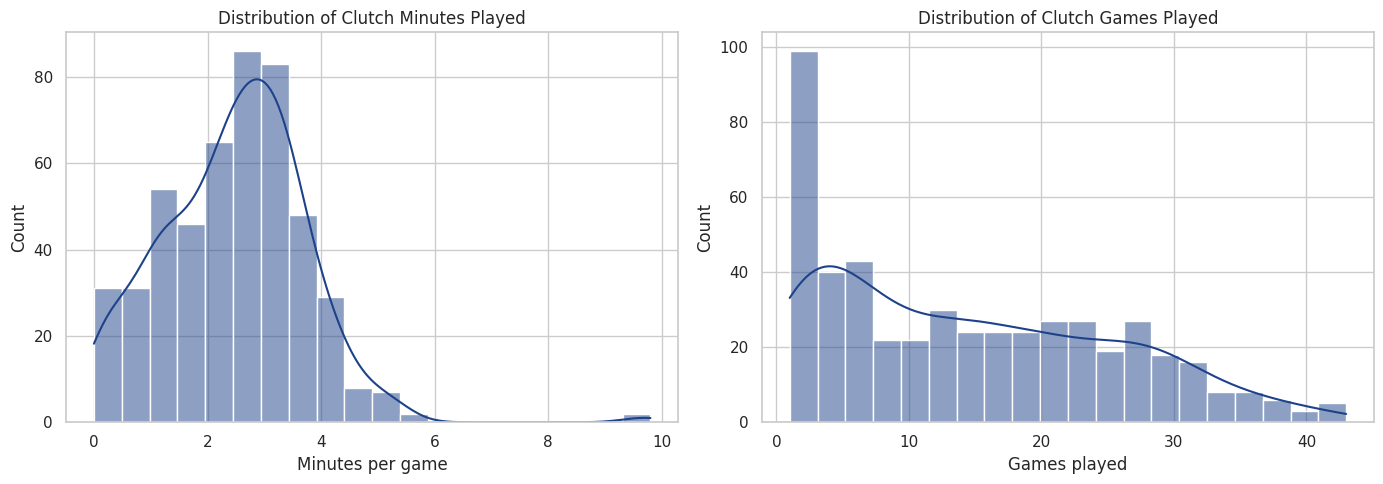

Clutch MIN
count    492.00
mean       2.46
std        1.28
min        0.00
25%        1.50
50%        2.50
75%        3.30
max        9.80

Clutch GP
count    492.00
mean      14.54
std       10.86
min        1.00
25%        5.00
50%       13.00
75%       23.00
max       43.00


In [12]:
# Distribution of clutch minutes and games played: used to determine filtering thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clutch['MIN'], bins=20, kde=True, ax=axes[0],
             color='#1d428a')
axes[0].set_title('Distribution of Clutch Minutes Played')
axes[0].set_xlabel('Minutes per game')

sns.histplot(df_clutch['GP'], bins=20, kde=True, ax=axes[1],
             color='#1d428a')
axes[1].set_title('Distribution of Clutch Games Played')
axes[1].set_xlabel('Games played')

plt.tight_layout()
plt.show()

# Summary stats
print('Clutch MIN')
print(df_clutch['MIN'].describe().round(2).to_string())
print('\nClutch GP')
print(df_clutch['GP'].describe().round(2).to_string())

**Feature Engineering**:
- Assist-to-turnover ratio (`AST_TOV_RATIO`): Assists divided by turnovers. Measures ball security and decision-making. A ratio of 2.0 means a player creates 2 assists for every 1 turnover. Higher = smarter with the ball under pressure.
- True shooting (`TRUE_SHOOTING`): Shooting efficiency accounting for 2s, 3s, and free throws. More complete than FG% alone.
- Points per minute in the clutch (`CLUTCH_PPM`): Points scored per minute exclusively in clutch situations (last 5 min, ≤5 pt game). Normalizes scoring to account for the short clutch time window.
- Points per minute overall (`OVR_PPM`): Points scored per minute across the full season. Used as the baseline to compare against clutch performance.
- Points clutch efficiency ratio (`PTS_CER`): CLUTCH_PPM divided by OVR_PPM. A value of 1.0 means the player scores at the same rate in clutch as overall. Above 1.0 = elevates under pressure. Below 1.0 = shrinks.
- Field goal percentage ratio (`FG_PCT_RATIO`): Clutch FG% divided by overall FG%. Same logic as PTS_CER but measuring shooting accuracy instead of scoring volume. Above 1.0 = shoots better when the game is on the line.

In [13]:
# Clean clutch data
# Focus on players with a minimum amount of clutch games played and clutch minutes per game to ensure meaningful analysis
MIN_CLUTCH_MINUTES = 3 # Minimum minutes played per game in clutch situations to be included in the analysis
MIN_CLUTCH_GAMES = 10 # Minimum games played in clutch situations to be included in the analysis

# Select relevant columns for analysis
clutch_cols = [
    'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION',
    'AGE', 'GP', 'MIN', 'FGM', 'FGA', 'FG_PCT',
    'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT',
    'PTS', 'AST', 'TOV', 'REB', 'STL', 'BLK',
    'PLUS_MINUS', 'W', 'L', 'W_PCT'
]

df_c = df_clutch[clutch_cols].copy()

# Filter: minimum clutch minutes played and minimum clutch games played
df_c = df_c[(df_c['MIN'] >= MIN_CLUTCH_MINUTES) & (df_c['GP'] >= MIN_CLUTCH_GAMES)].reset_index(drop=True)

# New features
df_c['AST_TOV_RATIO'] = (df_c['AST'] / df_c['TOV'].replace(0, np.nan)).round(2)
df_c['TRUE_SHOOTING'] = (
    df_c['PTS'] / (2 * (df_c['FGA'] + 0.44 * df_c['FTA']))
).round(3)

print(f'Players with ≥{MIN_CLUTCH_MINUTES} clutch minutes and ≥{MIN_CLUTCH_GAMES} clutch games: {len(df_c)}')
df_c.head(5)

Players with ≥3 clutch minutes and ≥10 clutch games: 143


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,PTS,AST,TOV,REB,STL,BLK,PLUS_MINUS,W,L,W_PCT,AST_TOV_RATIO,TRUE_SHOOTING
0,1631260,AJ Green,MIL,26.0,28,3.5,0.3,1.0,0.259,0.2,0.9,0.240,0.1,0.2,0.667,0.9,0.0,0.1,0.2,0.0,0.0,0.5,14,14,0.500,0.0,0.414
1,203932,Aaron Gordon,DEN,30.0,14,5.2,1.2,2.1,0.586,0.6,0.9,0.615,0.4,0.7,0.600,3.4,0.4,0.2,0.8,0.1,0.1,1.8,9,5,0.643,2.0,0.706
2,1630174,Aaron Nesmith,IND,26.0,20,3.5,0.5,1.2,0.391,0.2,0.8,0.267,0.2,0.3,0.500,1.3,0.2,0.1,0.9,0.1,0.2,-0.5,8,12,0.400,2.0,0.488
3,1641737,Adem Bona,PHI,23.0,16,3.3,0.2,0.3,0.600,0.0,0.0,0.000,0.1,0.3,0.500,0.5,0.1,0.1,0.5,0.0,0.3,0.9,9,7,0.563,1.0,0.579
4,1627936,Alex Caruso,OKC,32.0,19,3.3,0.3,1.1,0.286,0.3,0.7,0.385,0.0,0.0,0.000,0.9,0.3,0.1,0.8,0.3,0.1,1.8,14,5,0.737,3.0,0.409


In [14]:
# Merge with overall stats to compute differentials
overall_cols = ['PLAYER_ID', 'PTS', 'MIN', 'FG_PCT', 'AST', 'TOV', 'PLUS_MINUS']
df_o = df_overall[overall_cols].copy()
df_o.columns = ['PLAYER_ID', 'OVR_PTS', 'OVR_MIN', 'OVR_FG_PCT', 'OVR_AST', 'OVR_TOV', 'OVR_PLUS_MINUS']

df = df_c.merge(df_o, on='PLAYER_ID', how='left')

# Points per minute
df['CLUTCH_PPM'] = (df['PTS'] / df['MIN']).round(4)
df['OVR_PPM']   = (df['OVR_PTS'] / df['OVR_MIN']).round(4)

# Clutch Efficiency Ratio (1.0 = same, >1.0 = better in clutch)
df['PTS_CER'] = (df['CLUTCH_PPM'] / df['OVR_PPM']).round(3)

# Same logic for FG%
df['FG_PCT_RATIO'] = (df['FG_PCT'] / df['OVR_FG_PCT']).round(3)


print(f'Merged dataset: {df.shape[0]} players')
df[['PLAYER_NAME', 'PTS', 'OVR_PTS', 'FG_PCT', 'CLUTCH_PPM', 'OVR_PPM','PTS_CER', 'FG_PCT_RATIO']].head(8)

Merged dataset: 143 players


,PLAYER_NAME,PTS,OVR_PTS,FG_PCT,CLUTCH_PPM,OVR_PPM,PTS_CER,FG_PCT_RATIO
0,AJ Green,0.9,10.4,0.259,0.2571,0.3574,0.719,0.611
1,Aaron Gordon,3.4,16.2,0.586,0.6538,0.5806,1.126,1.179
2,Aaron Nesmith,1.3,13.8,0.391,0.3714,0.4646,0.799,0.944
3,Adem Bona,0.5,4.8,0.600,0.1515,0.2759,0.549,1.008
4,Alex Caruso,0.9,6.2,0.286,0.2727,0.3407,0.800,0.676
5,Alex Sarr,1.9,16.3,0.500,0.4419,0.5993,0.737,1.037
6,Alperen Sengun,2.4,20.4,0.439,0.6000,0.6126,0.979,0.846
7,Amen Thompson,1.7,18.3,0.510,0.4250,0.4893,0.869,0.955



## 4. Exploratory Analysis

With all the information gathered and the metrics developed, we can begin analyzing player performance, what they did in clutch moments throughout the season and how well they performed in those situations.

### 4.1 Top clutch scorers
The top clutch scorers are the players who averaged the most points per game during clutch time, highlighting the players who consistently delivered offensively in high-pressure situations.
For these 15 top scorers, the color of each bar represents their field goal percentage. This helps us understand not only how many points they scored in clutch situations, but also how efficiently they scored them. After all, scoring 10 points on 3-for-10 shooting is very different from scoring the same amount on 3-for-4 shooting.

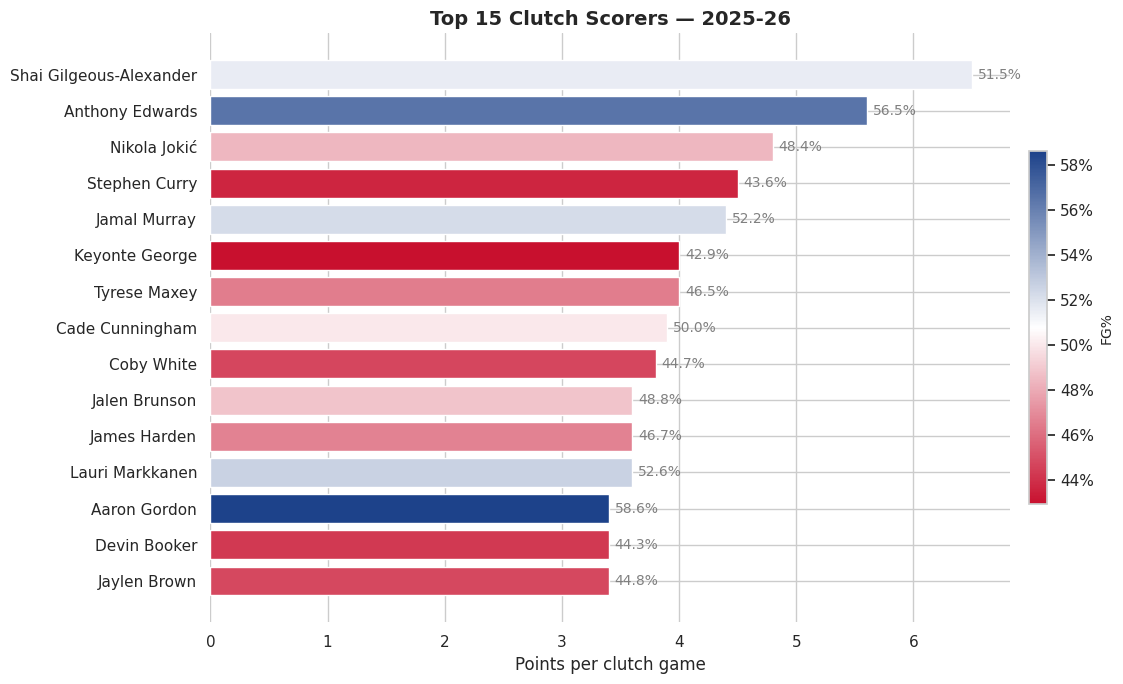

In [15]:
# Top 15 Clutch Scorers
top_scorers = df.nlargest(15, 'PTS')[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'PTS', 'FG_PCT']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

# Map FG% to a color scale
norm = plt.Normalize(top_scorers['FG_PCT'].min(), top_scorers['FG_PCT'].max())
colors = nba_cmap(norm(top_scorers['FG_PCT']))

bars = ax.barh(top_scorers['PLAYER_NAME'], top_scorers['PTS'], color=colors)

# FG% labels on each bar
for bar, fg in zip(bars, top_scorers['FG_PCT']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{fg:.1%}', va='center', fontsize=10, color='gray')

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap=nba_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('FG%', fontsize=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))


ax.invert_yaxis()
ax.set_xlabel('Points per clutch game', fontsize=12)
ax.set_title(f'Top 15 Clutch Scorers — {SEASON}', fontsize=14, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('top_clutch_scorers.png', dpi=150, bbox_inches='tight')
plt.show()

While the length of each bar represents clutch points per game, the color intensity represents each player’s field goal percentage (FG%) in those situations. This adds an efficiency layer to the analysis, allowing us to distinguish between players who scored a high volume of points efficiently and those who required more shot attempts to reach similar scoring totals.

For example, **Anthony Edwards and Aaron Gordon** combined strong scoring production with excellent shooting efficiency, while other players scored at high volume with more moderate percentages. Shai Gilgeous-Alexander led all players in clutch scoring, reinforcing both his offensive responsibility and consistency in late-game situations.

### 4.2 True shooting efficiency in clutch

This chart highlights the 15 players with the highest true shooting percentage (TS%) in clutch situations, considering only players who attempted at least 2 field goals per game during clutch time. True shooting percentage is an efficiency metric that accounts for field goals, three-pointers, and free throws, providing a more complete measure of scoring efficiency than regular field goal percentage.

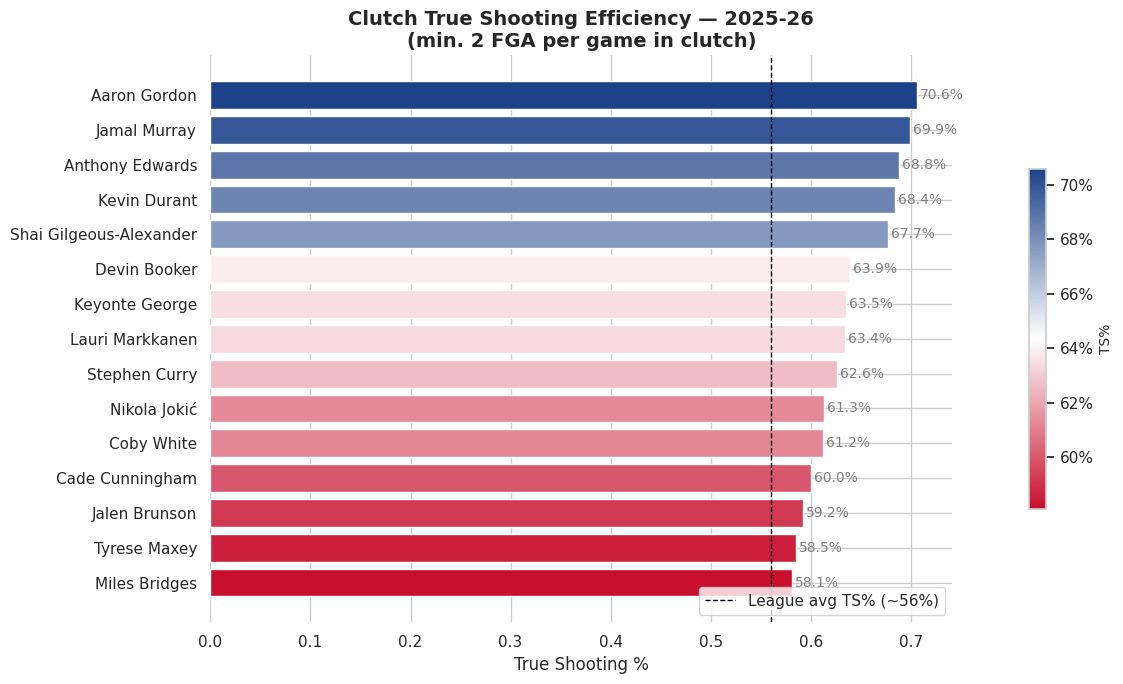

In [16]:
# True Shooting Efficiency (min 2 clutch FGA per game)
# Top 15 players with the highest true shooting percentage in clutch situations, among those who attempted at least 2 shots per game in clutch situations.

efficient = df[df['FGA'] >= 2].nlargest(15, 'TRUE_SHOOTING').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

# Color gradient: red (low), navy (high)
norm = plt.Normalize(efficient['TRUE_SHOOTING'].min(), efficient['TRUE_SHOOTING'].max())
colors = nba_cmap(norm(efficient['TRUE_SHOOTING']))

bars = ax.barh(efficient['PLAYER_NAME'], efficient['TRUE_SHOOTING'], color=colors)

# TS% labels on each bar
for bar, ts in zip(bars, efficient['TRUE_SHOOTING']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{ts:.1%}', va='center', fontsize=10, color='gray')

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap=nba_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.08)
cbar.set_label('TS%', fontsize=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax.axvline(0.56, color='black', linestyle='--', linewidth=1, label='League avg TS% (~56%)')
ax.invert_yaxis()
ax.set_xlabel('True Shooting %', fontsize=12)
ax.set_title(f'Clutch True Shooting Efficiency — {SEASON}\n(min. 2 FGA per game in clutch)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('clutch_true_shooting.png', dpi=150, bbox_inches='tight')
plt.show()

The dashed vertical line represents the league-average clutch TS% (~56%), making it easier to compare how much more efficient these players were in high-pressure moments. Players near the top, such as **Aaron Gordon and Jamal Murray**, were not only productive scorers but also extremely efficient, converting their opportunities at elite rates.

The color gradient reinforces this interpretation visually: bluer bars indicate higher efficiency, while redder tones represent lower,though still strong, efficiency levels relative to the rest of the league. Overall, this visualization helps identify which players combined scoring volume with elite shot-making efficiency when games were at their most critical.

### 4.3 Clutch +/- Leaders

The +/- statistic represents the point differential while a player is on the court, meaning a positive value indicates that the player’s team outscored opponents during clutch situations.

Unlike scoring-based metrics, clutch +/- captures overall influence on winning, including defense, playmaking, spacing, rebounding, and decision-making. A player may not lead the league in clutch scoring, but they can still have a major impact by contributing to efficient team possessions or preventing opponents from scoring.

This metric is especially useful because basketball is highly contextual. Some players elevate the entire team during high-pressure moments, even if their individual box score numbers are not dominant. Therefore, clutch +/- helps identify players whose presence consistently translated into positive outcomes when games were on the line.

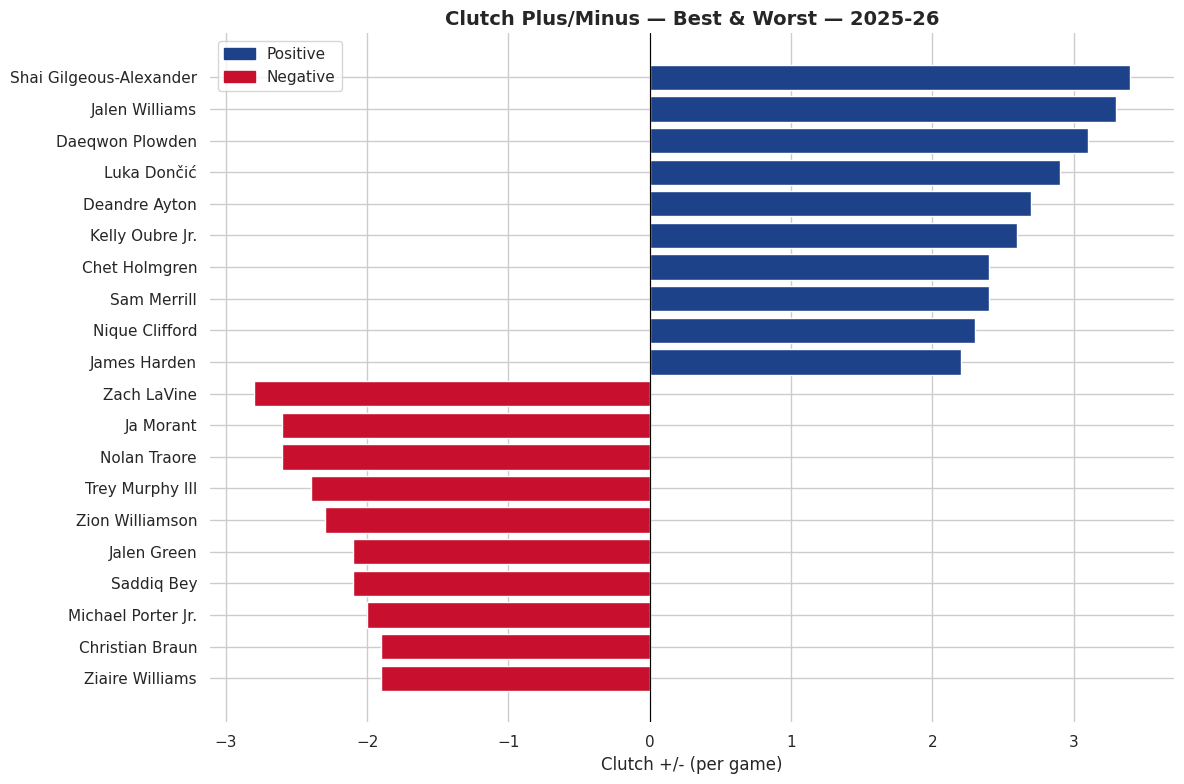

In [17]:
# Clutch +/- Leaders
pm_top    = df.nlargest(10, 'PLUS_MINUS')[['PLAYER_NAME', 'PLUS_MINUS', 'TEAM_ABBREVIATION']]
pm_bottom = df.nsmallest(10, 'PLUS_MINUS')[['PLAYER_NAME', 'PLUS_MINUS', 'TEAM_ABBREVIATION']]
pm_combined = pd.concat([pm_top, pm_bottom])

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#1d428a' if v > 0 else '#c8102e' for v in pm_combined['PLUS_MINUS']]
ax.barh(pm_combined['PLAYER_NAME'], pm_combined['PLUS_MINUS'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Clutch +/- (per game)', fontsize=12)
ax.set_title(f'Clutch Plus/Minus — Best & Worst — {SEASON}', fontsize=14, fontweight='bold')
pos_patch = mpatches.Patch(color='#1d428a', label='Positive')
neg_patch = mpatches.Patch(color='#c8102e', label='Negative')
ax.legend(handles=[pos_patch, neg_patch])
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('clutch_plus_minus.png', dpi=150, bbox_inches='tight')
plt.show()

**Blue bars** (positive) indicate players whose teams consistently win clutch situations when they
are on the floor. 

**Red bars** (negative) indicate players whose teams tend to lose those moments.

**Shai Gilgeous-Alexander** leads all players at +3.4, while several high-profile scorers like Ja Morant and Zach LaVine appear among the worst, suggesting that individual scoring in clutch doesn't always translate to winning. Other interesting names are **Luka Doncic, Chet Holmgren and James Harden**.

### 4.4 Assist-to-turnover ratio

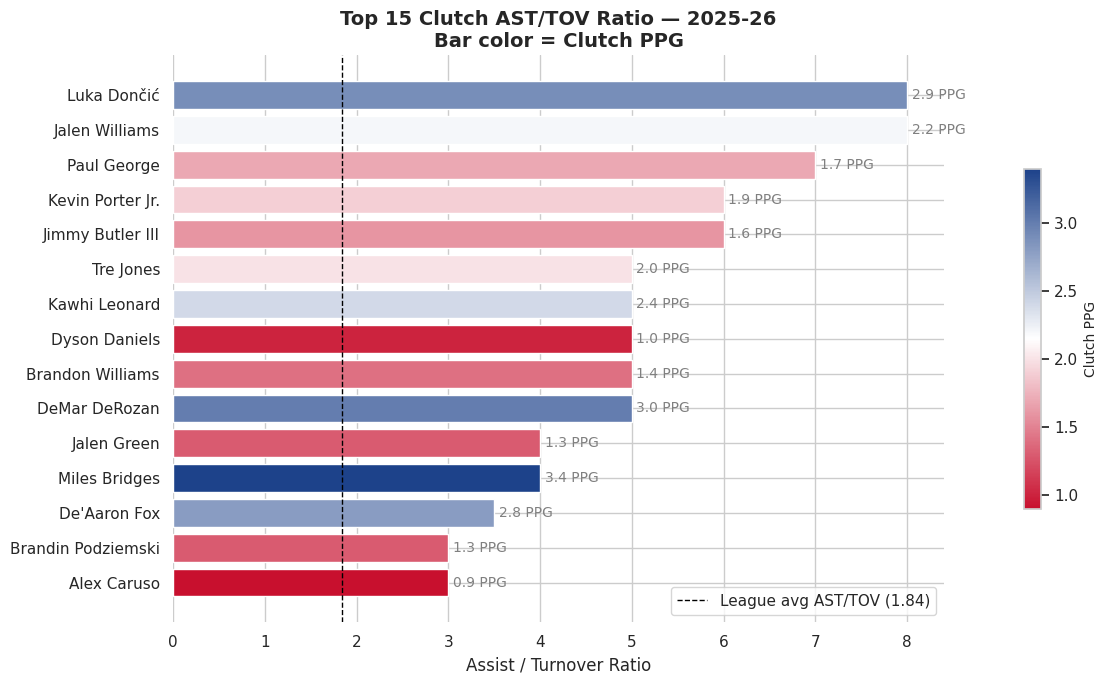

In [18]:
# Top 15 Clutch AST/TOV Ratio. Color = Clutch PPG
ast_top = df[df['AST'] >= 0.3].nlargest(15, 'AST_TOV_RATIO')[['PLAYER_NAME', 'AST_TOV_RATIO', 'PTS', 'TEAM_ABBREVIATION']].reset_index(drop=True)
ast_top = ast_top.sort_values('AST_TOV_RATIO')

fig, ax = plt.subplots(figsize=(12, 7))

# Normalize PTS to color scale
norm = plt.Normalize(ast_top['PTS'].min(), ast_top['PTS'].max())
colors = nba_cmap(norm(ast_top['PTS']))

bars = ax.barh(ast_top['PLAYER_NAME'], ast_top['AST_TOV_RATIO'], color=colors)

# PTS labels on each bar
for bar, pts in zip(bars, ast_top['PTS']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{pts:.1f} PPG', va='center', fontsize=10, color='gray')

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap=nba_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.08)
cbar.set_label('Clutch PPG', fontsize=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))

# Reference line at league avg ratio
ax.axvline(1.84, color='black', linestyle='--', linewidth=1, label='League avg AST/TOV (1.84)')

ax.set_xlabel('Assist / Turnover Ratio', fontsize=12)
ax.set_title(f'Top 15 Clutch AST/TOV Ratio — {SEASON}\nBar color = Clutch PPG', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('clutch_ast_tov_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

A high AST/TOV ratio reflects a player who makes smart decisions under pressure, creating scoring opportunities for teammates while protecting the ball when it matters most.

The bar color adds a second dimension: **clutch PPG**. Players in darker navy not only excel at ball security, but are also significant scoring threats in clutch situations, basically the most complete and demanding profile a player can have in a high-pressure moment.

**Luka Dončić and Jalen Williams** stand out as the clearest examples of this dual impact. Both rank among the top AST/TOV leaders while consistently contributing on the scoring end, reflecting their central role in their teams' clutch offenses.

Worth highlighting further is **Miles Bridges**, who posts the highest clutch PPG among these 15 players at 3.4 points per game, showing that elite ball security and scoring volume can coexist even outside of a team's primary offensive options.

### 4.5 Top 15 Scorers vs AST/TOV Ratio

Winning in clutch situations is rarely an individual effort, basketball is ultimately a team sport, and the best clutch performers understand that. Beyond scoring, the ability to make smart decisions, involve teammates, and protect the ball is what separates good clutch players from great ones.

This chart examines exactly that balance among the **top 15 clutch scorers**. Bar length represents clutch PPG, while bar color encodes AST/TOV ratio — **darker navy indicates better ball security and playmaking**, while red indicates a higher tendency to turn the ball over relative to assists.

The most valuable clutch players are those with both a long bar and a deep blue color: high scorers who also make their teammates better without giving the ball away.

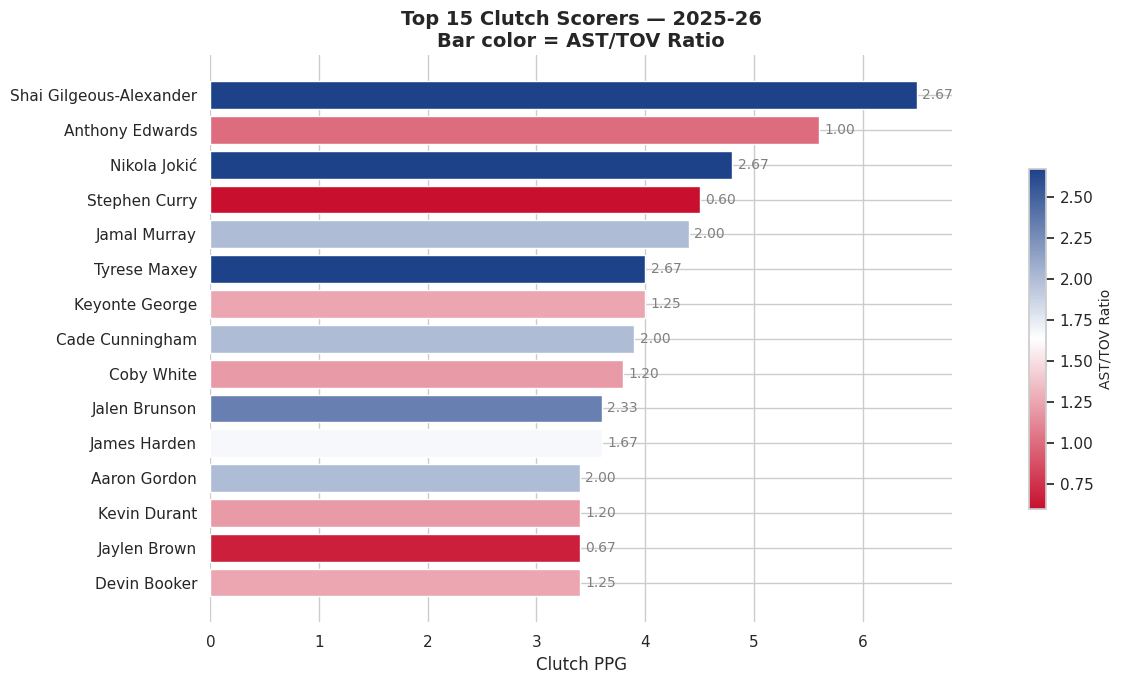

In [19]:
# Top 15 Clutch Scorers. Color = AST/TOV Ratio
ast_scorers = df[df['AST'] >= 0.3].nlargest(15, 'PTS')[['PLAYER_NAME', 'AST_TOV_RATIO', 'PTS', 'TEAM_ABBREVIATION']].reset_index(drop=True)
ast_scorers = ast_scorers.sort_values('PTS')

fig, ax = plt.subplots(figsize=(12, 7))

# Normalize AST_TOV_RATIO to color scale
norm = plt.Normalize(ast_scorers['AST_TOV_RATIO'].min(), ast_scorers['AST_TOV_RATIO'].max())
colors = nba_cmap(norm(ast_scorers['AST_TOV_RATIO']))

bars = ax.barh(ast_scorers['PLAYER_NAME'], ast_scorers['PTS'], color=colors)

# AST/TOV labels on each bar
for bar, ratio in zip(bars, ast_scorers['AST_TOV_RATIO']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{ratio:.2f}', va='center', fontsize=10, color='gray')

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap=nba_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.08)
cbar.set_label('AST/TOV Ratio', fontsize=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

ax.set_xlabel('Clutch PPG', fontsize=12)
ax.set_title(f'Top 15 Clutch Scorers — {SEASON}\nBar color = AST/TOV Ratio', fontsize=14, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('clutch_scorers_ast_tov.png', dpi=150, bbox_inches='tight')
plt.show()

**Shai Gilgeous-Alexander** stands alone at the top, not only the highest clutch scorer at 6.5 PPG, but also sharing the best AST/TOV ratio among these 15 players at 2.67. He is the most complete clutch performer in the league this season by this measure.

**Nikola Jokić** and **Tyrese Maxey** also post a 2.67 AST/TOV ratio while scoring consistently in clutch situations, reinforcing their reputation as high-IQ players who elevate their game without forcing plays.

On the other end, **Stephen Curry** and **Jaylen Brown** show the deepest red, both strong clutch scorers, but with AST/TOV ratios of 0.60 and 0.67 respectively, suggesting they
tend to operate in isolation mode under pressure, turning the ball over more frequently relative to their assists.

**Anthony Edwards** is perhaps the most interesting case, the second-highest clutch scorer at 5.8 PPG, yet with a ratio of exactly 1.00, meaning he creates one assist for every
turnover. Elite volume, but room to grow as a decision-maker in high-pressure moments.

## 5. Clutch vs Overall Stats Comparison

Who **elevates** their game vs who **shrinks**? A positive differential means the player performs *better* in clutch than overall.

A common assumption is that the best overall scorers are also the best clutch scorers. This chart challenges that idea. Each point represents one of the **top 20 clutch scorers**, plotted by their overall PPG (x-axis) vs their clutch PPG (y-axis).

The **dashed regression line** represents the expected clutch scoring given a player's overall output, players above the line score *more* in clutch than expected, while players below score *less*.

**Color encodes the Clutch Efficiency Ratio (CER):** navy points are players who score at a higher rate per minute in clutch than they do overall (elevators), while red points score at a lower rate (shrinkers). Dot size reflects clutch minutes played, larger dots indicate players who spend more time on the floor in clutch situations.

In [20]:
# Scatter: Clutch PTS vs Overall PTS
top20 = df.nlargest(20, 'PTS')

# Regression line: expected clutch PPG given overall PPG
x = top20['OVR_PTS'].values
y = top20['PTS'].values
coefs = P.polyfit(x, y, 1)
x_line = np.linspace(x.min() - 1, x.max() + 1, 100)
y_line = P.polyval(x_line, coefs)

fig = px.scatter(
    top20,
    x='OVR_PTS', y='PTS',
    text='PLAYER_NAME',
    color='PTS_CER',
    color_continuous_scale=nba_plotly_scale,
    color_continuous_midpoint=0,
    size='MIN',
    hover_data=['TEAM_ABBREVIATION', 'FG_PCT', 'TRUE_SHOOTING'],
    title=f'Clutch PTS vs Overall PTS — Top 20 Clutch Scorers ({SEASON})',
    labels={'OVR_PTS': 'Overall PPG', 'PTS': 'Clutch PPG', 'PTS_DIFF': 'Clutch uplift'}
)

# Regression reference line to understand which players are above/below expected clutch PPG based on their overall PPG
fig.add_trace(go.Scatter(
    x=x_line, y=y_line,
    mode='lines',
    line=dict(color='#1d428a', dash='dash', width=1.5),
    name='Expected clutch PPG',
    showlegend=True
))

fig.update_layout(
    height=520,
    template='plotly_white',
    legend=dict(
        x=0.01, y=0.99,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.7)',
        borderwidth=0
    )
)

fig.update_traces(textposition='top center', textfont_size=9,
                  selector=dict(mode='markers+text'))

# Clamp y-axis tightly to data range
y_pad = 0.8
fig.update_yaxes(range=[top20['PTS'].min() - y_pad,
                         top20['PTS'].max() + y_pad])

fig.update_layout(height=520, template='plotly_white')
fig.write_html('clutch_vs_overall_ppm_scatter.html')
fig.show()


The regression line confirms a **weak positive relationship** between overall scoring and clutch scoring. Players who score more in general tend to score slightly more in clutch, but the relationship is far from perfect, which is precisely what makes clutch performance interesting. 

**Shai Gilgeous-Alexander** is the clearest outlier, averaging 31 PPG overall and 6.5 PPG in clutch, sitting well above the regression line with the highest CER (darkest navy). He doesn't just score a lot, he actively raises his level when the game is on the line.

**Anthony Edwards** tells a similar story, high overall scorer who also outperforms expectations in clutch situations, reflected in his position above the line and his navy color.

On the opposite end, several high-volume scorers like **Jaylen Brown** and **Victor Wembanyama** sit below the regression line despite averaging over 26 PPG overall, meaning they actually score *less* than expected in clutch moments relative to their season averages.

Perhaps the most interesting group are the **left-side outliers**: players like **Aaron Gordon, Miles Bridges, and Coby White**, who average modest overall PPG (16–18) yet consistently deliver 3.5+ clutch PPG, sitting comfortably above the line. These are players whose impact in high-pressure moments far exceeds what their season averages would suggest.

**Clutch Efficiency Ratio (CER)**

A player averaging 30 PPG who scores 4 clutch PPG is not necessarily a better clutch performer than a player averaging 16 PPG who also scores 4 clutch PPG — the latter is doing so with far less overall offensive involvement. Raw clutch scoring alone doesn't tell the full story.

The **Clutch Efficiency Ratio (CER)** addresses this by comparing how efficiently a player scores *per minute* in clutch situations versus their overall season average:

A CER of **1.0** means the player scores at exactly the same rate in clutch as they do throughout the season. Above 1.0 means they elevate their scoring efficiency when the game
is on the line. The higher the value, the more they rise to the occasion. Below 1.0 means their scoring rate drops under pressure.

This metric levels the playing field between high-volume scorers and role players, making it possible to identify players who are genuinely more dangerous in clutch situations regardless of their overall offensive role.

In [21]:
# Bar chart: Clutch Efficiency Ratio: Clutch PPM / Overall PPM
diff_top = df.nlargest(15, 'PTS_CER')[['PLAYER_NAME', 'PTS_CER', 'TEAM_ABBREVIATION']].sort_values('PTS_CER')

fig = px.bar(
    diff_top,
    x='PTS_CER', y='PLAYER_NAME',
    orientation='h',
    color='PTS_CER',
    color_continuous_scale=nba_plotly_scale,
    color_continuous_midpoint=1,
    hover_data=['TEAM_ABBREVIATION'],
    title=f'Top 15 Clutch Efficiency Ratio — {SEASON}',
    labels={'PTS_CER': 'Clutch efficiency ratio', 'PLAYER_NAME': ''}
)
fig.add_vline(x=1, line_color='black', line_width=0.8)
fig.update_layout(height=600, template='plotly_white', showlegend=False,
                  coloraxis_showscale=False)
fig.write_html('clutch_efficiency_ratio.html')
fig.show()

Every player in this chart has a CER **above 1.0**, meaning all 15 score at a higher rate per minute in clutch situations than they do throughout the rest of the game. The vertical line at 1.0 serves as the reference point: anything to the right of it represents a genuine clutch elevation.

**Daeqwon Plowden** leads with a CER of 1.813, meaning he scores 80% more efficiently per minute in clutch situations than his season average, the most dramatic elevation in the
league among qualified players.

**Anthony Edwards** is the most significant name on this list given his star profile. A CER of 1.74 confirms that his clutch reputation is statistically justified. He doesn't just score a lot in general; he actively becomes a more efficient scorer when the game is decided.

**Shai Gilgeous-Alexander** appearing here is particularly noteworthy, he is already the league's top clutch scorer in raw PPG, and a CER of 1.50 shows he achieves that not just through volume but through genuine efficiency gains under pressure.

One broader takeaway: the presence of veterans like **James Harden, DeMar DeRozan, and Stephen Curry** alongside younger players like **Cade Cunningham and Nolan Traore** suggests that clutch efficiency is not purely a product of experience, it is a skill distributed across generations.

## 6. Interactive Dashboard

A combined multi-panel Plotly dashboard saved as a standalone HTML file you can share.

In [ ]:
# Clutch Performance Dashboard
top_n = 10

# Each panel uses its own top 10 by relevant stat
top_ppg = df.nlargest(top_n, 'PTS').sort_values('PTS')
top_cer = df.nlargest(top_n, 'PTS_CER').sort_values('PTS_CER')
top_ast = df[df['AST'] >= 0.3].nlargest(top_n, 'AST_TOV_RATIO').sort_values('AST_TOV_RATIO')
top_pm  = df.nlargest(top_n, 'PLUS_MINUS').sort_values('PLUS_MINUS')

fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"colspan": 2}, None],
        [{}, {}],
        [{"colspan": 2}, None],
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# Panel 1 (wide): PPG scatter colored by TS%, sized by minutes
fig.add_trace(go.Scatter(
    x=top_ppg['PTS'],
    y=top_ppg['TRUE_SHOOTING'],
    mode='markers+text',
    text=top_ppg['PLAYER_NAME'],
    textposition='top center',
    textfont=dict(size=9),
    marker=dict(
        size=top_ppg['MIN'] * 6,
        color=top_ppg['TRUE_SHOOTING'],
        colorscale=nba_plotly_scale,
        showscale=True,
        colorbar=dict(title='TS%', tickformat='.0%', len=0.3, y=0.88, x=1.02)
    ),
    customdata=top_ppg['MIN'],
    hovertemplate='%{text}<br>Clutch PPG: %{x:.1f}<br>TS%: %{y:.1%}<br>Clutch MIN: %{customdata:.1f}<extra></extra>',
    name='PPG vs TS%'
), row=1, col=1)

# Panel 2 (left): CER bar chart
fig.add_trace(go.Bar(
    x=top_cer['PTS_CER'], y=top_cer['PLAYER_NAME'],
    orientation='h',
    marker=dict(color=top_cer['PTS_CER'], colorscale=nba_plotly_scale, cmid=1, showscale=False),
    hovertemplate='%{y}<br>CER: %{x:.3f}<extra></extra>',
    name='CER'
), row=2, col=1)
fig.add_vline(x=1, line_color='black', line_width=0.8, row=2, col=1)

# Panel 3 (right): AST/TOV bar chart
fig.add_trace(go.Bar(
    x=top_ast['AST_TOV_RATIO'], y=top_ast['PLAYER_NAME'],
    orientation='h',
    marker=dict(color=top_ast['AST_TOV_RATIO'], colorscale=nba_plotly_scale, showscale=False),
    hovertemplate='%{y}<br>AST/TOV: %{x:.2f}<extra></extra>',
    name='AST/TOV'
), row=2, col=2)

# Panel 4 (wide): +/- colored by Win %
fig.add_trace(go.Bar(
    x=top_pm['PLUS_MINUS'], y=top_pm['PLAYER_NAME'],
    orientation='h',
    marker=dict(
        color=top_pm['W_PCT'], colorscale=nba_plotly_scale, showscale=True,
        colorbar=dict(title='Win %', tickformat='.0%', len=0.3, y=0.12, x=1.02)
    ),
    customdata=top_pm['W_PCT'],
    hovertemplate='%{y}<br>+/-: %{x:.2f}<br>Win%: %{customdata:.0%}<extra></extra>',
    name='+/- & Win%'
), row=3, col=1)

# Layout
fig.update_layout(
    height=1000,
    title_text=f'NBA Clutch Performance Dashboard — {SEASON}',
    title_font_size=20,
    template='plotly_white',
    showlegend=False
)

fig.update_xaxes(title_text='Clutch PPG', row=1, col=1)
fig.update_yaxes(title_text='True Shooting %', tickformat='.0%', row=1, col=1)
fig.update_xaxes(title_text='CER', row=2, col=1)
fig.update_xaxes(title_text='AST/TOV Ratio', row=2, col=2)
fig.update_xaxes(title_text='Clutch +/- (per game)', row=3, col=1)

# Panel titles (set manually due to colspan layout)
panel_titles = [
    dict(text=f'Top {top_n} Clutch Scorers — PPG vs True Shooting %', x=0.5,  y=1.05),
    dict(text=f'Top {top_n} Clutch Efficiency Ratio (CER)',            x=0.100, y=0.650),
    dict(text=f'Top {top_n} AST/TOV Ratio',                           x=0.775, y=0.650),
    dict(text=f'Top {top_n} Clutch +/- — color = Win %',              x=0.5,  y=0.260),
]
for t in panel_titles:
    fig.add_annotation(text=t['text'], xref='paper', yref='paper',
                       x=t['x'], y=t['y'], showarrow=False, font=dict(size=13))

fig.write_html('nba_clutch_dashboard.html')
print('Dashboard saved as nba_clutch_dashboard.html')
fig.show()

Dashboard saved as nba_clutch_dashboard.html


## 7. Key Insights


### Findings

- **Top clutch scorer:** `Shai Gilgeous-Alexander` dominated clutch situations with `6.5` PPG and a `67.7%` TS%. Elite scoring volume and efficiency combined in the most pressure-filled moments of the game.
- **Most efficient shooter:** `Jamal Murray` posted the highest TS% (`69.9%`) among the top 10 clutch scorers, converting at an exceptional rate while contributing `4.4` PPG, a player who may not always take the most shots, but makes them count when it matters.
- **Best clutch +/-:** `Shai Gilgeous-Alexander` leads at `+3.4` per game, meaning his team consistently outscores opponents when he is on the floor in clutch situations. This is further validated by his `74%` clutch win percentage, one of the highest in the league.
- **Ball security in clutch:** `Jalen Williams` and `Luka Dončić` share the best AST/TOV ratio at `8.0`. For every turnover, they create 8 assists in clutch situations. This reflects not only elite decision-making under pressure, but also their ability to elevate teammates when the game is on the line.
- **Biggest clutch elevator (CER):** `Daeqwon Plowden` leads with a CER of `1.81`, the most dramatic scoring efficiency uplift in the league. Close behind, `Anthony Edwards` posts a CER of `1.74`, meaning he scores `74%` more efficiently per minute in clutch situations than his season average, confirming that his reputation as a clutch performer is fully backed by the data.

**Best Clutch Player of the Season:** The data points consistently to one name: `Shai Gilgeous-Alexander`. He leads the league in clutch scoring, posts the best +/- among qualified players, and does so on a winning team with a `74%` clutch win percentage. Across every dimension this analysis measures, volume, efficiency, and winning, he stands alone.

### Limitations

- Sample sizes in clutch situations are small, stats can be volatile.
- Plus/minus is influenced by teammates and opponents, not just individual performance.
- Some players may play heavy clutch minutes on losing teams (skewing +/- downward despite good individual play).

### Possible next steps

- Add shot charts for top clutch scorers
- Compare clutch performance across multiple seasons
- Build a clutch score composite metric
- Add team-level clutch analysis

In [51]:
# Export clean dataset
export_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT',
    'MIN', 'PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT',
    'TRUE_SHOOTING', 'AST', 'TOV', 'AST_TOV_RATIO', 'REB', 'STL', 'BLK',
    'PLUS_MINUS', 'CLUTCH_PPM', 'OVR_PPM', 'PTS_CER',
    'OVR_PTS', 'OVR_FG_PCT', 'FG_PCT_RATIO'
]
df[export_cols].to_csv('nba_clutch_stats.csv', index=False)
print(f'Clean dataset exported → nba_clutch_stats.csv ({len(df)} players)')

Clean dataset exported → nba_clutch_stats.csv (143 players)
